In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("emissions_cleaned.tsv", sep="\t")
df.head()

/tmp/ipykernel_324/1183210294.py:1: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("emissions_cleaned.tsv", sep="\t")


,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,airpol,src_crf,geo,total_emissoes,diferença_total,country,sector_main,meta_2030,gap_2030,redução_%_atual
0,0.05434,0.04967,0.04875,0.04633,0.03952,0.0404,0.03945,0.03695,0.03621,0.03636,...,CH4,CRF1,AT,1.18065,-0.03019,Austria,Energia,0.02445,-0.00030,-56.0
1,0.06409,0.05937,0.05342,0.05452,0.04838,0.04837,0.04849,0.04531,0.04376,0.04321,...,CH4,CRF1,BE,1.51007,-0.02475,Belgium,Energia,0.02884,0.01050,-39.0
2,0.09971,0.08446,0.0938,0.09466,0.08749,0.08974,0.08973,0.08154,0.07289,0.06002,...,CH4,CRF1,BG,2.32696,-0.05324,Bulgaria,Energia,0.04487,0.00160,-53.0
3,0.00051,0.00052,0.00052,0.00052,0.00054,0.00056,0.00058,0.00057,0.00058,0.00059,...,CH4,CRF1,CY,0.02057,0.00017,Cyprus,Energia,0.00023,0.00045,33.0
4,0.45396,0.4141,0.38199,0.39465,0.37544,0.3684,0.3678,0.35565,0.33804,0.30677,...,CH4,CRF1,CZ,7.97993,-0.38201,Czech Republic,Energia,0.20428,-0.13233,-84.0


In [4]:
year_columns = [col for col in df.columns if col.isdigit()]

In [5]:
df_long = df.melt(
    id_vars=["country"],   # podes adicionar mais colunas fixas depois
    value_vars=year_columns,
    var_name="year",
    value_name="emissions"
)

df_long.head()

,country,year,emissions
0,Austria,1990,0.05434
1,Belgium,1990,0.06409
2,Bulgaria,1990,0.09971
3,Cyprus,1990,0.00051
4,Czech Republic,1990,0.45396


In [7]:
df_long["emissions"] = pd.to_numeric(df_long["emissions"], errors="coerce")

In [8]:
df_long["emissions"].isna().sum()

1360

In [9]:
total_by_year = df_long.groupby("year", as_index=False)["emissions"].sum()
total_by_year.head()

,year,emissions
0,1990,4.900928e+07
1,1991,4.755129e+07
2,1992,4.630534e+07
3,1993,4.548323e+07
4,1994,4.533306e+07


In [10]:
df_long["year"] = df_long["year"].astype(int)
total_by_year = df_long.groupby("year", as_index=False)["emissions"].sum().sort_values("year")
total_by_year.head()

,year,emissions
0,1990,4.900928e+07
1,1991,4.755129e+07
2,1992,4.630534e+07
3,1993,4.548323e+07
4,1994,4.533306e+07


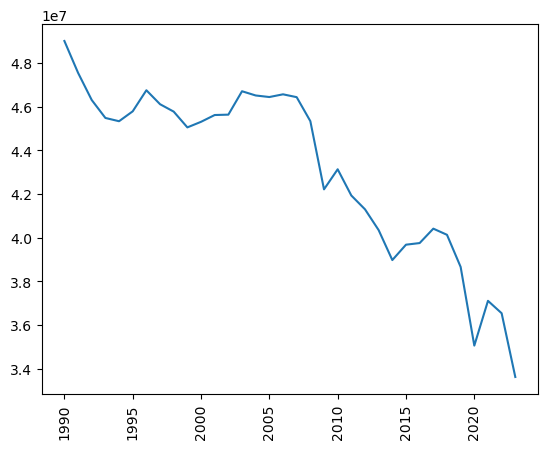

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(total_by_year["year"], total_by_year["emissions"])
plt.xticks(rotation=90)
plt.show()

In [16]:
total_by_year.to_csv("total_by_year.csv", index=False)
total_by_year.to_excel("total_by_year.xlsx", index=False)
import os
os.listdir()

['total_by_year.csv',
 'total_by_year.xlsx',
 '.ipynb_checkpoints',
 'emissions_cleaned.tsv',
 'Untitled.ipynb']

In [17]:
year_columns = [col for col in df.columns if col.isdigit()]

df_long = df.melt(
    id_vars=["country", "sector_main"],   # manter país e setor
    value_vars=year_columns,
    var_name="year",
    value_name="emissions"
)

df_long["emissions"] = pd.to_numeric(df_long["emissions"], errors="coerce")
df_long["year"] = df_long["year"].astype(int)

In [18]:
sector_table = df_long.pivot_table(
    values="emissions",
    index="country",
    columns="sector_main",
    aggfunc="sum"
)

sector_table.head()

sector_main,Agricultura,Energia,Memo,Outro,Outros,Processos Industriais,Resíduos,Uso do Solo e Florestas (LULUCF)
country,,,,,,,,
Austria,1.615907e+06,1.813825e+07,5.341933e+06,NaN,NaN,3.017798e+06,2.550374e+06,-1.952556e+06
Belgium,2.031802e+06,3.195841e+07,9.126381e+06,NaN,0.0,4.697500e+06,6.396288e+05,-2.549206e+05
Bulgaria,1.234020e+06,1.348511e+07,3.863522e+06,2500.36787,0.0,1.263799e+06,7.824328e+05,-2.526489e+06
Croatia,6.390756e+05,5.705283e+06,1.558587e+06,0.00000,0.0,6.083256e+05,9.607010e+05,-1.366023e+06
Cyprus,1.067826e+05,2.026773e+06,5.547286e+05,599.63904,0.0,1.968108e+05,1.130595e+05,-4.843680e+04


In [19]:
sector_2023 = df_long[df_long["year"] == 2023].pivot_table(
    values="emissions",
    index="country",
    columns="sector_main",
    aggfunc="sum"
)

sector_2023.head()


sector_main,Agricultura,Energia,Memo,Outro,Outros,Processos Industriais,Resíduos,Uso do Solo e Florestas (LULUCF)
country,,,,,,,,
Austria,45182.79766,454865.72131,148670.57205,NaN,NaN,90735.98534,69008.70977,48383.72539
Belgium,52508.33588,765449.53485,196640.13369,NaN,0.0,89534.42498,7113.29619,-2255.31306
Bulgaria,35771.11538,297718.67125,82250.21805,0.0000,0.0,22418.18579,15315.34004,-49167.22811
Croatia,14165.34119,170791.46084,45378.43310,0.0000,0.0,19136.59748,41519.71824,-32402.14978
Cyprus,3231.02780,62033.15118,16748.83210,13.3133,0.0,7972.72476,3509.23573,-1904.50260


In [20]:
sector_2023.to_excel("sector_2023.xlsx")

In [21]:
import os
os.listdir()

['sector_2023.xlsx',
 'total_by_year.csv',
 'total_by_year.xlsx',
 '.ipynb_checkpoints',
 'emissions_cleaned.tsv',
 'Untitled.ipynb']

In [22]:
sector_pct_2023 = sector_2023.div(sector_2023.sum(axis=1), axis=0) * 100
sector_pct_2023.round(2)

sector_main,Agricultura,Energia,Memo,Outro,Outros,Processos Industriais,Resíduos,Uso do Solo e Florestas (LULUCF)
country,,,,,,,,
Austria,5.27,53.09,17.35,NaN,NaN,10.59,8.05,5.65
Belgium,4.73,69.02,17.73,NaN,0.0,8.07,0.64,-0.20
Bulgaria,8.85,73.64,20.34,0.00,0.0,5.54,3.79,-12.16
Croatia,5.48,66.05,17.55,0.00,0.0,7.40,16.06,-12.53
Cyprus,3.53,67.72,18.28,0.01,0.0,8.70,3.83,-2.08
Czech Republic,3.70,61.40,17.89,0.08,0.0,6.37,12.24,-1.68
Denmark,15.43,62.26,18.79,0.13,NaN,2.03,1.75,-0.40
Estonia,6.43,62.87,16.61,NaN,NaN,0.96,3.43,9.69
Finland,5.30,48.55,13.55,0.01,0.0,4.01,17.06,11.52


In [23]:
sector_1990 = df_long[df_long["year"] == 1990].pivot_table(
    values="emissions",
    index="country",
    columns="sector_main",
    aggfunc="sum"
)

variation = sector_2023 - sector_1990
variation.head()

sector_main,Agricultura,Energia,Memo,Outro,Outros,Processos Industriais,Resíduos,Uso do Solo e Florestas (LULUCF)
country,,,,,,,,
Austria,-6828.86204,-17568.19064,-64.51445,NaN,NaN,9298.39911,-6007.46146,122950.43761
Belgium,-16278.86260,-175408.99376,-99499.44004,NaN,0.0,-63067.68468,-22206.44426,11761.46972
Bulgaria,-39004.36540,-287366.83976,-98708.32972,-89.30922,0.0,-35879.29345,-16810.51372,53243.97078
Croatia,-12627.89528,-18988.54958,-11456.96552,0.00000,0.0,-5497.90241,26261.04481,5097.04195
Cyprus,466.08562,24323.34905,5724.07836,-1.86186,0.0,3614.14053,849.76892,-980.76979


In [24]:
ranking_2023 = df_long[df_long["year"] == 2023] \
    .groupby("country")["emissions"].sum() \
    .sort_values(ascending=False)

ranking_2023.head(10)

country
Germany           7.622658e+06
France            4.405863e+06
Italy             3.773236e+06
Poland            3.378887e+06
Spain             2.619942e+06
Netherlands       1.643000e+06
Czech Republic    1.127837e+06
Belgium           1.108990e+06
Austria           8.568475e+05
Greece            7.273951e+05
Name: emissions, dtype: float64

In [25]:
total_1990 = df_long[df_long["year"] == 1990].groupby("country")["emissions"].sum()
total_2023 = df_long[df_long["year"] == 2023].groupby("country")["emissions"].sum()

reduction = ((total_2023 - total_1990) / total_1990) * 100
reduction.sort_values().head()

country
Romania     -67.921624
Estonia     -61.433142
Lithuania   -60.927037
Bulgaria    -51.224989
Slovakia    -51.052754
Name: emissions, dtype: float64

In [26]:
sector_2023.idxmax(axis=1)

country
Austria                                    Energia
Belgium                                    Energia
Bulgaria                                   Energia
Croatia                                    Energia
Cyprus                                     Energia
Czech Republic                             Energia
Denmark                                    Energia
Estonia                                    Energia
Finland                                    Energia
France                                     Energia
Germany                                    Energia
Greece                                     Energia
Hungary                                    Energia
Iceland           Uso do Solo e Florestas (LULUCF)
Ireland                                    Energia
Italy                                      Energia
Latvia                                     Energia
Lithuania                                  Energia
Luxembourg                                 Energia
Malta                  

In [29]:
with pd.ExcelWriter("analise_emissoes.xlsx") as writer:
    total_by_year.to_excel(writer, sheet_name="Total_by_Year", index=False)
    sector_2023.reset_index().to_excel(writer, sheet_name="Sector_2023", index=False)
    sector_pct_2023.reset_index().to_excel(writer, sheet_name="Sector_%_2023", index=False)
    ranking_2023.reset_index().to_excel(writer, sheet_name="Ranking_2023", index=False)
    reduction.reset_index().to_excel(writer, sheet_name="Reduction_%_1990_2023", index=False)
    variation.reset_index().to_excel(writer, sheet_name="Variation_1990_2023", index=False)

In [28]:
import os
os.listdir()

['sector_2023.xlsx',
 'total_by_year.csv',
 'total_by_year.xlsx',
 'analise_emissoes.xlsx',
 '.ipynb_checkpoints',
 'emissions_cleaned.tsv',
 'Untitled.ipynb']